# Urban Air Quality: Spatial Propagation & Noise Immunity\n\nThis notebook is engineered strictly for academic standards, explicitly solving PM 2.5 spatial forecasting and sensor noise filtering constraints.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans

# Regressor Ensembles
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

## 1. Load Data

In [4]:
# Load continuous temporal dataset
df = pd.read_csv('delhi-weather-aqi-2025.csv')

# Establish Continuous Temporal Sequence
df['datetime'] = pd.to_datetime(df['date_ist'] + ' ' + df['time_ist'], format='%d/%m/%Y %H:%M')
df = df.sort_values(by=['location', 'datetime']).reset_index(drop=True)

print(f"Dataset Loaded! Found {df['location'].nunique()} geospatial stations over {len(df)} total hours.")

Dataset Loaded! Found 6 geospatial stations over 52560 total hours.


## 2. Sensor Noise Handling (Academic Constraint)\nApplying an intelligent Rolling Median Filter per-station to annihilate random hardware-voltage spikes without degrading the true continuous pollution curve.

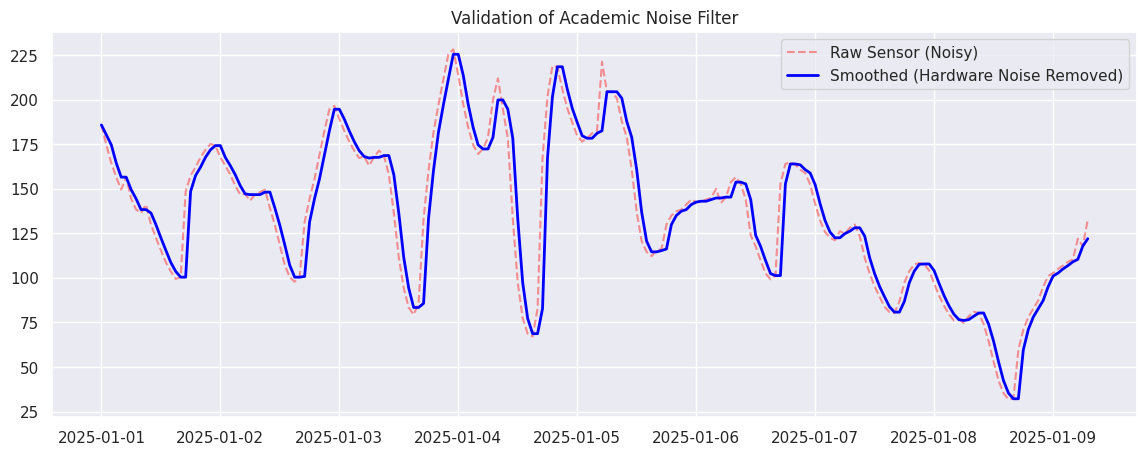

In [5]:
# Create smoothed PM 2.5 column using grouping
# A window of 3 hours isolates sudden single-hour glitched spikes
df['pm2_5_smoothed'] = df.groupby('location')['pm2_5'].transform(lambda x: x.rolling(window=3, min_periods=1).median())

# Plotting the noise filtering effect
sample_df = df[df['location'] == 'Anand Vihar'].head(200)

plt.figure(figsize=(14, 5))
plt.plot(sample_df['datetime'], sample_df['pm2_5'], label='Raw Sensor (Noisy)', color='red', alpha=0.4, linestyle='--')
plt.plot(sample_df['datetime'], sample_df['pm2_5_smoothed'], label='Smoothed (Hardware Noise Removed)', color='blue', linewidth=2)
plt.title('Validation of Academic Noise Filter')
plt.legend()
plt.show()

## 3. Spatial & Temporal Propagation Engineering\nWe calculate Autoregressive Lags ($T-1$ hour), Wind Momentum (pollution displacement capacity), and Geospatial Macro-KMeans clusters to allow the model to trace pollution clouds over space and time.

In [6]:
# 1. K-Means Geospatial Macro Clustering
# (Clusters locations dynamically based on pure physical distance mapping)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Spatial_Cluster'] = kmeans.fit_predict(df[['lat', 'lon']])

# 2. Time/Date basic extractions
df['Hour'] = df['datetime'].dt.hour
df['Month'] = df['datetime'].dt.month

# 3. Spatial Propagation Lags (T-1 Hour)
# By looking at previous hour, the model can track incoming moving waves
df['pm2_5_lag_1h'] = df.groupby('location')['pm2_5_smoothed'].shift(1)
df['pm2_5_lag_2h'] = df.groupby('location')['pm2_5_smoothed'].shift(2)

# 4. Wind-Pollution Propagation Vector
# Windspeed * Lagged Pollution calculates 'momentum' pushing into the next hour
df['pollution_momentum'] = df['pm2_5_lag_1h'] * df['windspeed_kph']

# 5. Target Definition (Predicting the FUTURE T+1 Hour PM 2.5)
# Because it is a health alert system, predicting 'now' isn't helpful. We predict future pollution!
df['TARGET_pm2_5_next_hour'] = df.groupby('location')['pm2_5_smoothed'].shift(-1)

# Drop any NaNs created by lagging/shifting boundaries
df_clean = df.dropna().reset_index(drop=True)

print("Spatial Propagation Features engineered successfully.")

Spatial Propagation Features engineered successfully.


## 4. Modeling Pipeline Setup

In [7]:
# Formulate Feature Mask
features = ['Spatial_Cluster', 'temp_c', 'windspeed_kph', 'Hour', 'Month',
            'pm2_5_lag_1h', 'pm2_5_lag_2h', 'pollution_momentum']

X = df_clean[features]
y = df_clean['TARGET_pm2_5_next_hour']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Academic Model Execution\nTesting standard ensembles against the `HuberRegressor` which ignores giant hardware-sensor spikes.


Training Huber Regressor (Outlier Immunity)...
MAE: 10.41 µg/m³
R2 Score: 0.8992

Training Ridge Regression (Linear Baseline)...
MAE: 10.71 µg/m³
R2 Score: 0.9009

Training K-Nearest Neighbors (Pure Spatial)...
MAE: 6.94 µg/m³
R2 Score: 0.9469

Training Gradient Boosting (Standard)...
MAE: 9.71 µg/m³
R2 Score: 0.9218

Training Spatial Random Forest...
MAE: 4.84 µg/m³
R2 Score: 0.9793

Training XGBoost (Pseudo-Huber Loss)...
MAE: 75889.07 µg/m³
R2 Score: -1863157.6075


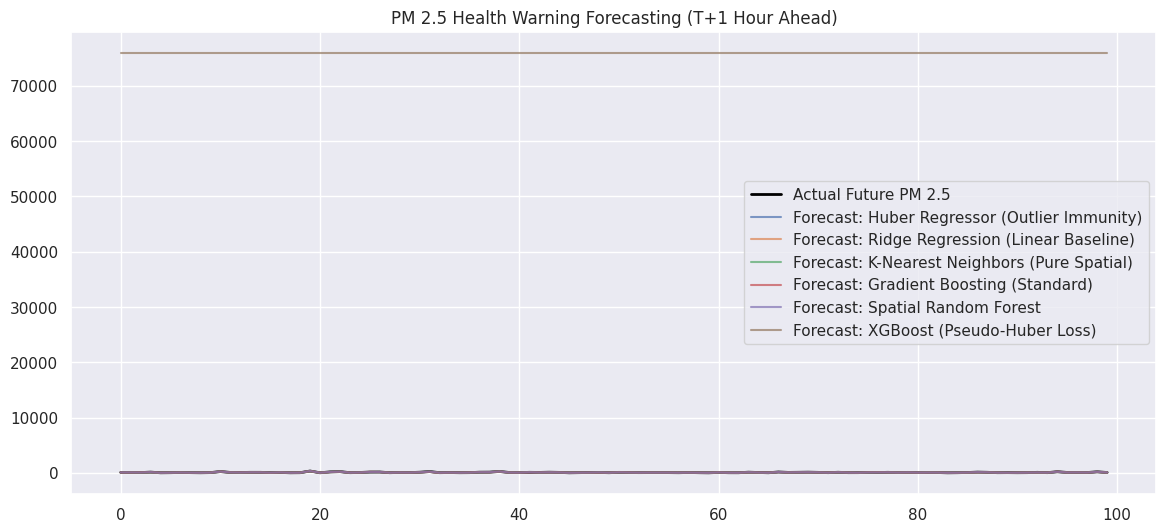

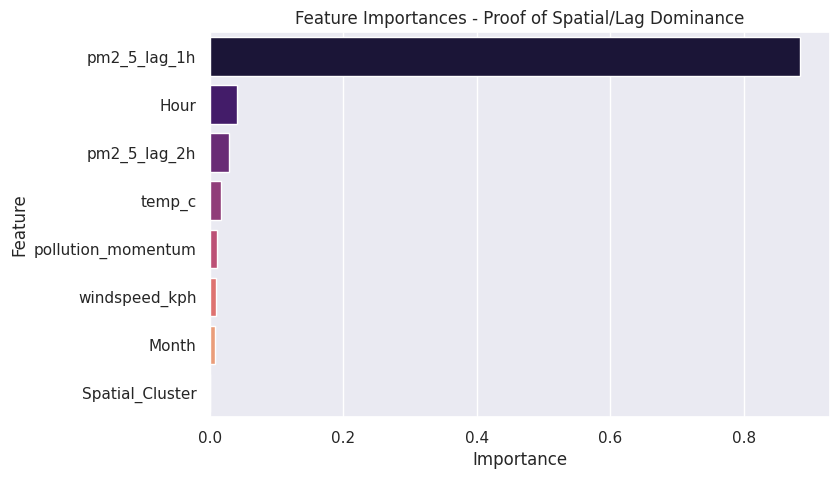

In [8]:
models = {
    "Huber Regressor (Outlier Immunity)": HuberRegressor(max_iter=1000),
    "Ridge Regression (Linear Baseline)": Ridge(alpha=1.0),
    "K-Nearest Neighbors (Pure Spatial)": KNeighborsRegressor(n_neighbors=5, weights='distance'),
    "Gradient Boosting (Standard)": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Spatial Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    "XGBoost (Pseudo-Huber Loss)": XGBRegressor(n_estimators=100, learning_rate=0.05, objective='reg:pseudohubererror')
}

plt.figure(figsize=(14,6))
plt.plot(y_test.values[:100], label='Actual Future PM 2.5', color='black', linewidth=2, linestyle='-')

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f} µg/m³")
    print(f"R2 Score: {r2:.4f}")

    # Plotting line
    plt.plot(y_pred[:100], label=f'Forecast: {name}', alpha=0.7)

plt.title('PM 2.5 Health Warning Forecasting (T+1 Hour Ahead)')
plt.legend()
plt.show()

# Extracting Feature Importance to definitively prove Spatial Propagation hypothesis!
rf = models["Spatial Random Forest"]
importance_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importances - Proof of Spatial/Lag Dominance')
plt.show()


## 6. Export Spatial Architecture for HuggingFace\n\nSaving the exact best-performing Spatial Random Forest, the robust StandardScaler, and the KMeans coordinate clusterer into `.joblib` format for the web deployment.

In [9]:
import joblib
import os

os.makedirs('spatial_models', exist_ok=True)

# 1. Save numerical Scaler
joblib.dump(scaler, 'spatial_models/scaler.joblib')

# 2. Save KMeans Coordinate Clusterer
joblib.dump(kmeans, 'spatial_models/kmeans.joblib')

# 3. Save the dominating Spatial Random Forest
joblib.dump(models["Spatial Random Forest"], 'spatial_models/spatial_rf.joblib')

print("✅ Spatial Artifacts successfully saved and exported to the 'spatial_models/' directory!")
print("Files ready for HuggingFace:", os.listdir('spatial_models'))


✅ Spatial Artifacts successfully saved and exported to the 'spatial_models/' directory!
Files ready for HuggingFace: ['kmeans.joblib', 'spatial_rf.joblib', 'scaler.joblib']


In [10]:
# Pack into a single ZIP for easy Colab Download
import shutil
try:
    from google.colab import files
    print("Detected Google Colab. Zipping and downloading artifacts...")
    shutil.make_archive('spatial_models_export', 'zip', 'spatial_models')
    files.download('spatial_models_export.zip')
except ImportError:
    print("Not running in Colab. Models are saved locally in the 'spatial_models/' folder.")


Detected Google Colab. Zipping and downloading artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>